# Module 2 Fire Event Analysis
**Event:** 2020 Cameron Peak Fire (Aug 13-Dec 2, 2020; 208,913 acres; largest wildfire in Colorado history at the time)

Computes dNBR and classifies burn severity by comparing pre- and post-fire
scenes, and pulls FIRMS-style active-fire detections for the event window.

In [1]:
import matplotlib.pyplot as plt
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

pre_scene = data_access.get_optical_scene(BBOX, "2020-06-01", seed=100)
post_scene = data_access.get_optical_scene(BBOX, "2020-10-15", seed=200)

## Differenced Normalized Burn Ratio (dNBR)

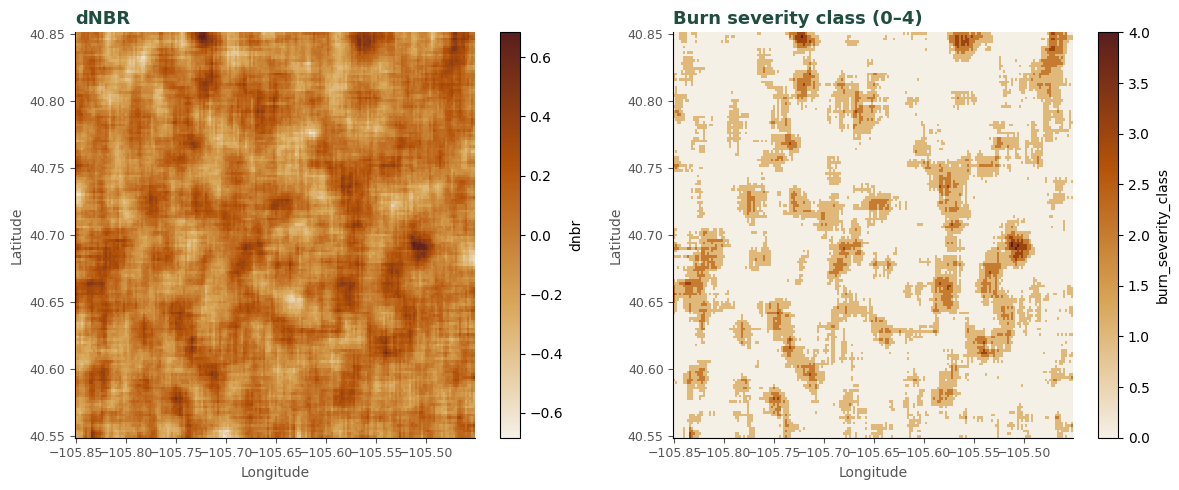

      unburned: 72.3% of scene
           low: 22.8% of scene
  moderate-low:  4.5% of scene
 moderate-high:  0.4% of scene
          high:  0.0% of scene


In [2]:
burn = indicators.dnbr(pre_scene, post_scene)
severity_class = indicators.burn_severity_class(burn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
viz.plot_raster(burn, title="dNBR", ax=axes[0], cmap=viz.SEVERITY_CMAP)
viz.plot_raster(severity_class, title="Burn severity class (0–4)", ax=axes[1], cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/02_dnbr_severity.png", dpi=150)
plt.show()

import numpy as np
labels = severity_class.attrs["labels"]
for code, label in labels.items():
    frac = float((severity_class == code).mean())
    print(f"{label:>14}: {frac:5.1%} of scene")

## MTBS-style burn severity product (independent cross-check)

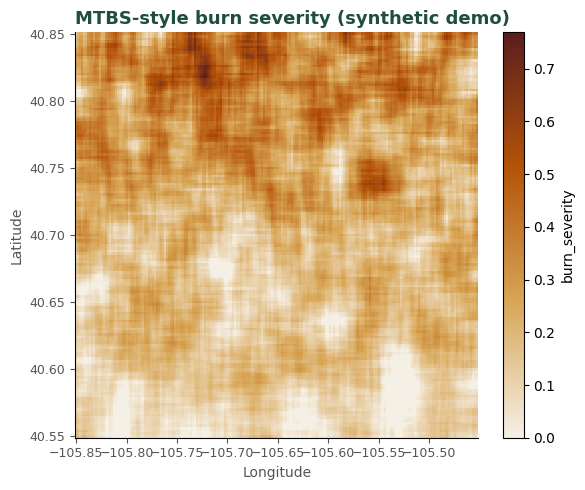

In [3]:
mtbs_severity = data_access.get_burn_severity(BBOX, fire_year=REGION.fire_year)
fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(mtbs_severity, title="MTBS-style burn severity (synthetic demo)", ax=ax, cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/02_mtbs_severity.png", dpi=150)
plt.show()

## FIRMS-style active fire detections during the event window

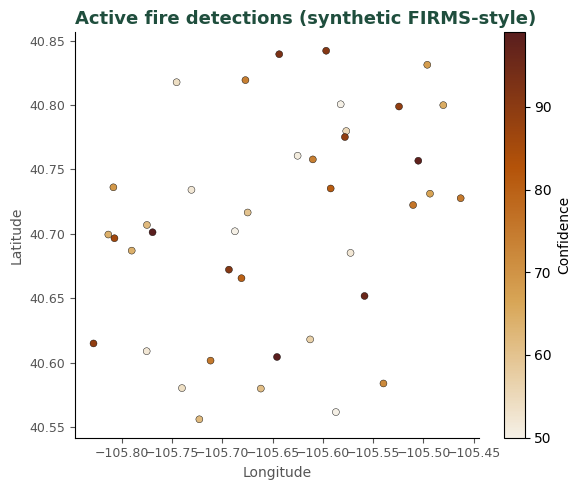

,lon,lat,confidence,acq_date
0,-105.745355,40.817672,54,2020-08-13 00:00:00.000000
1,-105.730604,40.734115,52,2020-08-15 20:18:27.692307
2,-105.524310,40.798807,89,2020-08-18 16:36:55.384615
3,-105.813234,40.699417,64,2020-08-21 12:55:23.076923
4,-105.609960,40.757755,74,2020-08-24 09:13:50.769230


In [4]:
detections = data_access.get_fire_detections(BBOX, ("2020-08-13", "2020-12-02"))
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(detections["lon"], detections["lat"], c=detections["confidence"],
                 cmap=viz.SEVERITY_CMAP, s=25, edgecolor="k", linewidth=0.3)
viz.style_axes(ax, title="Active fire detections (synthetic FIRMS-style)", xlabel="Longitude", ylabel="Latitude")
plt.colorbar(sc, ax=ax, label="Confidence")
plt.tight_layout()
plt.savefig("../outputs/02_fire_detections.png", dpi=150)
plt.show()

detections.head()

## Summary

`mtbs_severity` (an independent product-style estimate) and `severity_class`
(derived from our own dNBR) are the two burn-severity views Module 3 and 4
build on. In a live deployment, `mtbs_severity` would come directly from
MTBS's actual event-mapped severity product for Cameron Peak once it's
released, and `severity_class` would be computed from real pre/post
Sentinel-2 scenes, useful as a faster, more current cross-check between
MTBS release cycles.
